In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data **Exploration**

In [133]:

df = pd.read_csv('/content/Reviews.csv',engine='python',on_bad_lines='skip',quoting=3)
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,"""Product arrived labeled as Jumbo Salted Peanu..."
2,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
3,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
4,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...
5,14,B001GVISJM,A18ECVX2RJ7HUE,"""willie """"roadie""""""",2,2,4,1288915200,fresh and greasy!,good flavor! these came securely packed... the...
6,15,B001GVISJM,A2MUGFV2TDQ47K,"""Lynrie """"Oh HELL no""""""",4,5,5,1268352000,Strawberry Twizzlers - Yummy,The Strawberry Twizzlers are my guilty pleasur...
7,17,B001GVISJM,A3KLWF6WQ5BNYO,Erica Neathery,0,0,2,1348099200,poor taste,I love eating them and they are good for watch...
8,18,B001GVISJM,AFKW14U97Z6QO,Becca,0,0,5,1345075200,Love it!,I am very satisfied with my Twizzler purchase....
9,20,B001GVISJM,A3IV7CL2C13K2U,Greg,0,0,5,1318032000,Home delivered twizlers,Candy was delivered very fast and was purchase...


In [134]:
df.tail()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
149383,568432,B003XUL27E,A32Y0419QFGVHM,Kevin Mitchell,0,0,1,1319673600,Mostly water,Definitely not worth buying flavored water wit...
149384,568442,B000NY8O9M,AZRHU8CP5XKMF,David L. Brown,0,0,5,1264204800,Great For Fast Gulasch!,Quick and easy! Had similar Gulasch in Guest H...
149385,568443,B006T7TKZO,A3BOURUK79CYY5,BIH,0,0,5,1338854400,Great Cafe Latte,This product is great. Gives you so much ener...
149386,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
149387,568453,B004I613EE,A3IBEVCTXKNOH,"""Kathy A. Welch """"katwel""""""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149388 entries, 0 to 149387
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      149388 non-null  int64 
 1   ProductId               149388 non-null  object
 2   UserId                  149388 non-null  object
 3   ProfileName             149372 non-null  object
 4   HelpfulnessNumerator    149388 non-null  int64 
 5   HelpfulnessDenominator  149388 non-null  int64 
 6   Score                   149388 non-null  int64 
 7   Time                    149388 non-null  int64 
 8   Summary                 149388 non-null  object
 9   Text                    149388 non-null  object
dtypes: int64(5), object(5)
memory usage: 11.4+ MB


In [136]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,149388.000000,149388.000000,149388.000000,149388.000000,1.493880e+05
mean,286089.040452,1.102967,1.539735,4.312415,1.296740e+09
std,164339.850473,3.457614,4.183909,1.275790,4.805868e+07
min,1.000000,0.000000,0.000000,1.000000,9.440928e+08
25%,144101.500000,0.000000,0.000000,4.000000,1.270771e+09
50%,288745.000000,0.000000,0.000000,5.000000,1.312330e+09
75%,428013.500000,1.000000,2.000000,5.000000,1.333584e+09
max,568453.000000,466.000000,488.000000,5.000000,1.351210e+09


In [137]:
df.duplicated().sum()

np.int64(0)

In [138]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,16
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


In [139]:
df.dropna(subset=['ProfileName'],inplace=True)

In [140]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


In [141]:
df.shape

(149372, 10)

In [142]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

☝

# Data **Cleaning**

In [143]:
import re # دي مكتبه عشان تحذف اي حاجه مش حروف
def clean_text(Text):
  Text =Text.lower()
  Text=re.sub(r'<.*?>','',Text)
  Text=re.sub(r'[^a-zA-Z]',' ',Text)
  return Text
df['Text']=df['Text'].apply(clean_text)
df['Text']


,Text
0,i have bought several of the vitality canned d...
1,product arrived labeled as jumbo salted peanu...
2,if you are looking for the secret ingredient i...
3,right now i m mostly just sprouting this so my...
4,this is a very healthy dog food good for thei...
...,...
149383,definitely not worth buying flavored water wit...
149384,quick and easy had similar gulasch in guest h...
149385,this product is great gives you so much ener...
149386,great for sesame chicken this is a good if no...


In [144]:
def get_sentiment(score):
    if score >= 4:
        return "positive"
    elif score == 3:
        return "neutral"
    else:
        return "negative"

df['sentiment'] = df['Score'].apply(get_sentiment)
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,i have bought several of the vitality canned d...,positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,product arrived labeled as jumbo salted peanu...,negative
2,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,if you are looking for the secret ingredient i...,negative
3,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,right now i m mostly just sprouting this so my...,positive
4,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,this is a very healthy dog food good for thei...,positive


In [145]:
df.drop(columns=['UserId', 'Id'], inplace=True)

In [146]:
df['ProfileName'].value_counts()

,count
ProfileName,
"""M. Hammond """"ColemanFlGuy""""""",161
John,92
Pen Name,91
Linda,90
Chris,88
...,...
C. Keck,1
Jonathan Antunez,1
"""J-Bird """"J-Bird""""""",1


In [147]:
df.head()

,ProductId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment
0,B001E4KFG0,delmartian,1,1,5,1303862400,Good Quality Dog Food,i have bought several of the vitality canned d...,positive
1,B00813GRG4,dll pa,0,0,1,1346976000,Not as Advertised,product arrived labeled as jumbo salted peanu...,negative
2,B000UA0QIQ,Karl,3,3,2,1307923200,Cough Medicine,if you are looking for the secret ingredient i...,negative
3,B000E7L2R4,R. James,1,1,5,1322006400,Yay Barley,right now i m mostly just sprouting this so my...,positive
4,B00171APVA,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,this is a very healthy dog food good for thei...,positive


In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149372 entries, 0 to 149387
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   ProductId               149372 non-null  object
 1   ProfileName             149372 non-null  object
 2   HelpfulnessNumerator    149372 non-null  int64 
 3   HelpfulnessDenominator  149372 non-null  int64 
 4   Score                   149372 non-null  int64 
 5   Time                    149372 non-null  int64 
 6   Summary                 149372 non-null  object
 7   Text                    149372 non-null  object
 8   sentiment               149372 non-null  object
dtypes: int64(4), object(5)
memory usage: 11.4+ MB


In [149]:
product_counts = df['ProductId'].value_counts()
print(product_counts.head(10))

ProductId
B007JFMH8M    401
B0026RQTGE    234
B002QWP89S    234
B002QWHJOU    234
B002QWP8H0    234
B005K4Q1YA    215
B005K4Q37A    215
B005K4Q34S    215
B005K4Q4LK    215
B0013A0QXC    171
Name: count, dtype: int64


In [150]:
product_counts_df = df['ProductId'].value_counts().reset_index()
product_counts_df.columns = ['ProductId', 'ReviewCount']

print(product_counts_df.head())

    ProductId  ReviewCount
0  B007JFMH8M          401
1  B0026RQTGE          234
2  B002QWP89S          234
3  B002QWHJOU          234
4  B002QWP8H0          234


In [151]:
product_sentiment = df.groupby('ProductId')['Score'].mean().reset_index()
product_sentiment.columns = ['ProductId', 'AvgScore']

print(product_sentiment.head())

    ProductId  AvgScore
0  0006641040  4.375000
1  2734888454  5.000000
2  2841233731  5.000000
3  7310172001  4.741935
4  7310172101  4.741935


In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149372 entries, 0 to 149387
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   ProductId               149372 non-null  object
 1   ProfileName             149372 non-null  object
 2   HelpfulnessNumerator    149372 non-null  int64 
 3   HelpfulnessDenominator  149372 non-null  int64 
 4   Score                   149372 non-null  int64 
 5   Time                    149372 non-null  int64 
 6   Summary                 149372 non-null  object
 7   Text                    149372 non-null  object
 8   sentiment               149372 non-null  object
dtypes: int64(4), object(5)
memory usage: 11.4+ MB


In [153]:
df['sentiment'].value_counts()

,count
sentiment,
positive,122732
negative,19331
neutral,7309


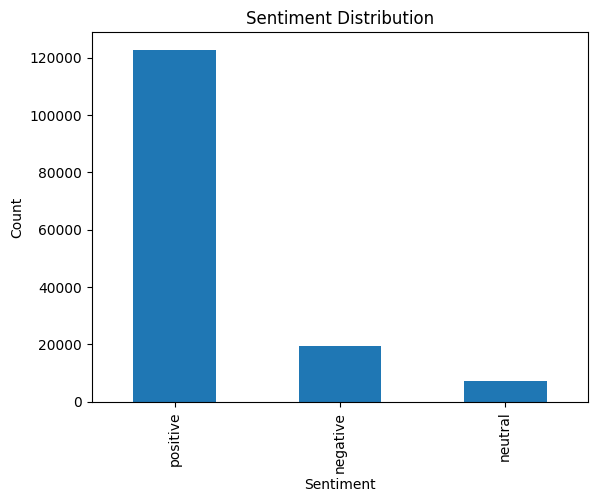

In [154]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()
#محتاجين نعدل الوضع عشان كده فيه imbalance

In [155]:
df.columns

Index(['ProductId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text',
       'sentiment'],
      dtype='object')

In [156]:
df['text_len']=df['Text'].apply(len)


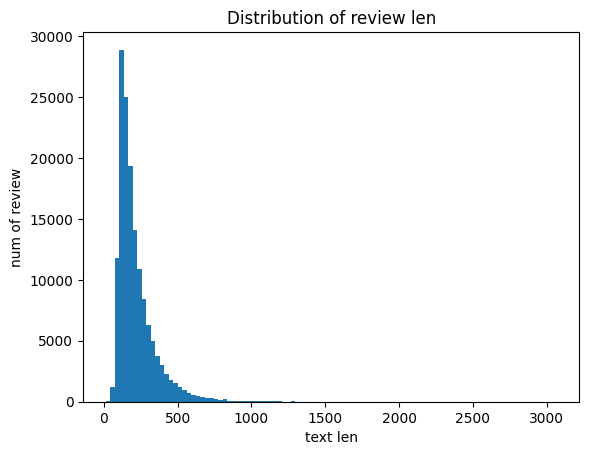

In [157]:
plt.hist(df['text_len'],bins=100)
plt.title('Distribution of review len')
plt.xlabel('text len')
plt.ylabel('num of review')
plt.show()

In [158]:
df['text_len'].describe()

,text_len
count,149372.000000
mean,216.224620
std,133.405652
min,12.000000
25%,130.000000
50%,176.000000
75%,259.000000
max,3068.000000


In [159]:
#حذف الكلمات المتكرره اللي ملهاش معني
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = ENGLISH_STOP_WORDS

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

df['Text'] = df['Text'].apply(remove_stopwords)

In [160]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english',ngram_range=(1, 2),min_df=5,max_df=0.9)
df['text_len'] = df['Text'].apply(len)
df['word_count'] = df['Text'].apply(lambda x: len(x.split()))
df['exclamation'] = df['Text'].apply(lambda x: x.count('!'))

In [161]:
pip install wordcloud

In [162]:
from wordcloud import WordCloud
np.negative_text = ' '.join(df[df['sentiment'] == 'negative']['Text'])
wordcloud = WordCloud(width=800, height=400, background_color='white',stopwords='english').generate(np.negative_text)

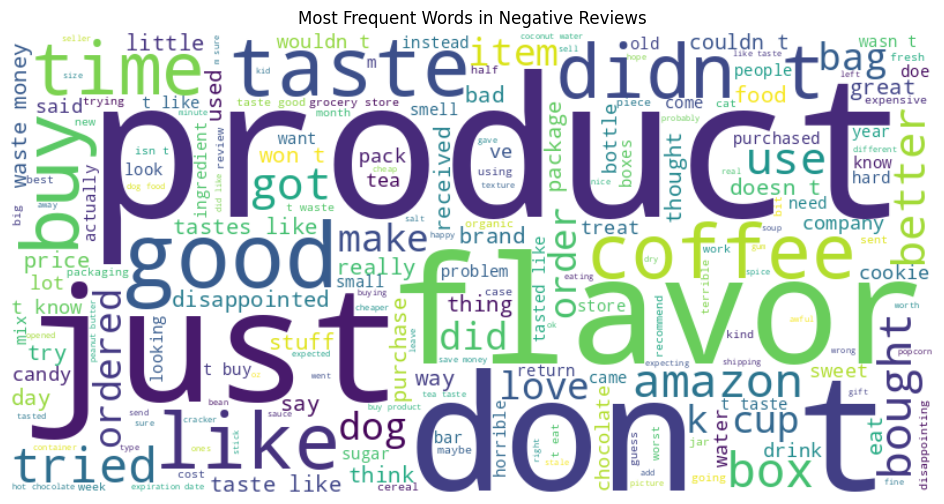

In [163]:
plt.figure(figsize=(12,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Negative Reviews')
plt.show()

In [164]:
from wordcloud import WordCloud
np.positive_text = ' '.join(df[df['sentiment'] == 'positive']['Text'])
wordcloud = WordCloud(width=800, height=400, background_color='white',stopwords='english').generate(np.positive_text)

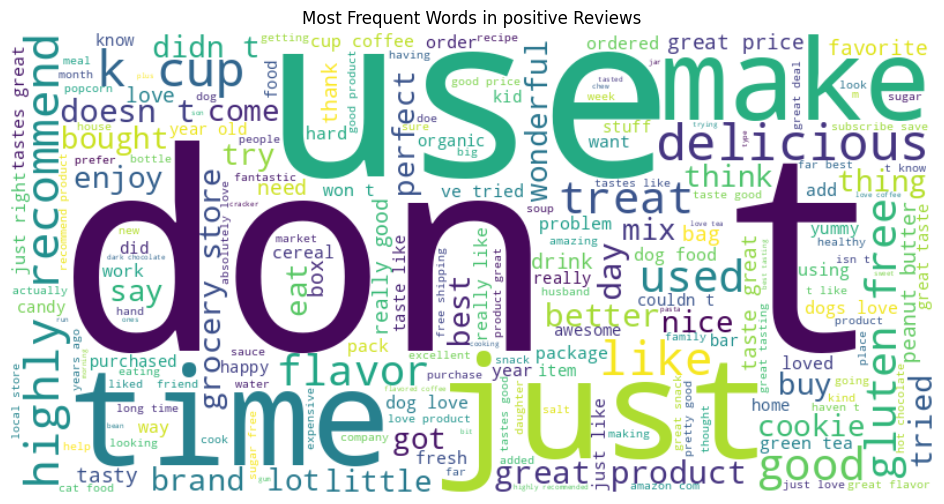

In [165]:
plt.figure(figsize=(12,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in positive Reviews')
plt.show()

In [166]:
df['combined'] = df['Summary'] + " " + df['Text']

In [167]:
df

,ProductId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment,text_len,word_count,exclamation,combined
0,B001E4KFG0,delmartian,1,1,5,1303862400,Good Quality Dog Food,bought vitality canned dog food products good ...,positive,150,21,0,Good Quality Dog Food bought vitality canned d...
1,B00813GRG4,dll pa,0,0,1,1346976000,Not as Advertised,product arrived labeled jumbo salted peanuts p...,negative,133,18,0,Not as Advertised product arrived labeled jumb...
2,B000UA0QIQ,Karl,3,3,2,1307923200,Cough Medicine,looking secret ingredient robitussin believe g...,negative,117,16,0,Cough Medicine looking secret ingredient robit...
3,B000E7L2R4,R. James,1,1,5,1322006400,Yay Barley,right m just sprouting cats eat grass love rot...,positive,64,11,0,Yay Barley right m just sprouting cats eat gra...
4,B00171APVA,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,healthy dog food good digestion good small pup...,positive,76,12,0,Healthy Dog Food healthy dog food good digesti...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149383,B003XUL27E,Kevin Mitchell,0,0,1,1319673600,Mostly water,definitely worth buying flavored water teaspoo...,negative,105,17,0,Mostly water definitely worth buying flavored ...
149384,B000NY8O9M,David L. Brown,0,0,5,1264204800,Great For Fast Gulasch!,quick easy similar gulasch guest houses german...,positive,122,19,0,Great For Fast Gulasch! quick easy similar gul...
149385,B006T7TKZO,BIH,0,0,5,1338854400,Great Cafe Latte,product great gives energy tastes great try ca...,positive,75,11,0,Great Cafe Latte product great gives energy ta...
149386,B001EO7N10,Lettie D. Carter,0,0,5,1299628800,Will not do without,great sesame chicken good better resturants ea...,positive,75,11,0,Will not do without great sesame chicken good ...


In [168]:
X = df['combined']
y = df['sentiment']

In [169]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [177]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [179]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [180]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('model', LogisticRegression(max_iter=1000))
])
scores = cross_val_score(pipeline,df['Text'],df['sentiment'],cv=5,scoring='accuracy')
print(scores)
print(scores.mean())

[0.9092887  0.91029289 0.90637344 0.91213095 0.91079199]
0.9097755936159204


In [181]:
y_pred = model.predict(X_test)

In [182]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.873673640167364


In [183]:
from sklearn.metrics import confusion_matrix

cm =confusion_matrix(y_test, y_pred)
print(cm)

[[ 3257   474   176]
 [  279   968   196]
 [  926  1723 21876]]


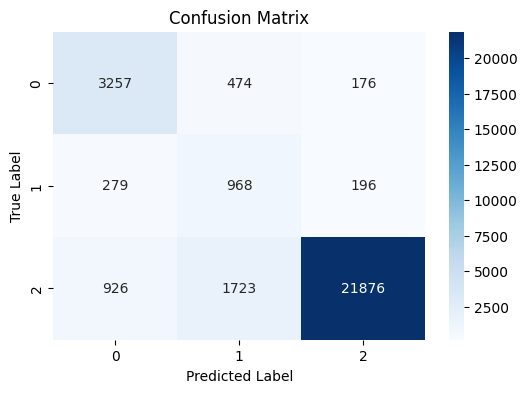

In [184]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [185]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.73      0.83      0.78      3907
     neutral       0.31      0.67      0.42      1443
    positive       0.98      0.89      0.94     24525

    accuracy                           0.87     29875
   macro avg       0.67      0.80      0.71     29875
weighted avg       0.92      0.87      0.89     29875



In [186]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight='balanced')
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

In [187]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    negative       0.80      0.83      0.81      3907
     neutral       0.47      0.54      0.51      1443
    positive       0.97      0.96      0.96     24525

    accuracy                           0.92     29875
   macro avg       0.75      0.78      0.76     29875
weighted avg       0.92      0.92      0.92     29875



In [188]:
from sklearn.svm import SVC
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [189]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9261924686192469


In [190]:
import joblib
joblib.dump(model, 'model.pkl')

['model.pkl']